# What is Automation
A **predictable** set of predetermined actions that transfer data from one point to another.


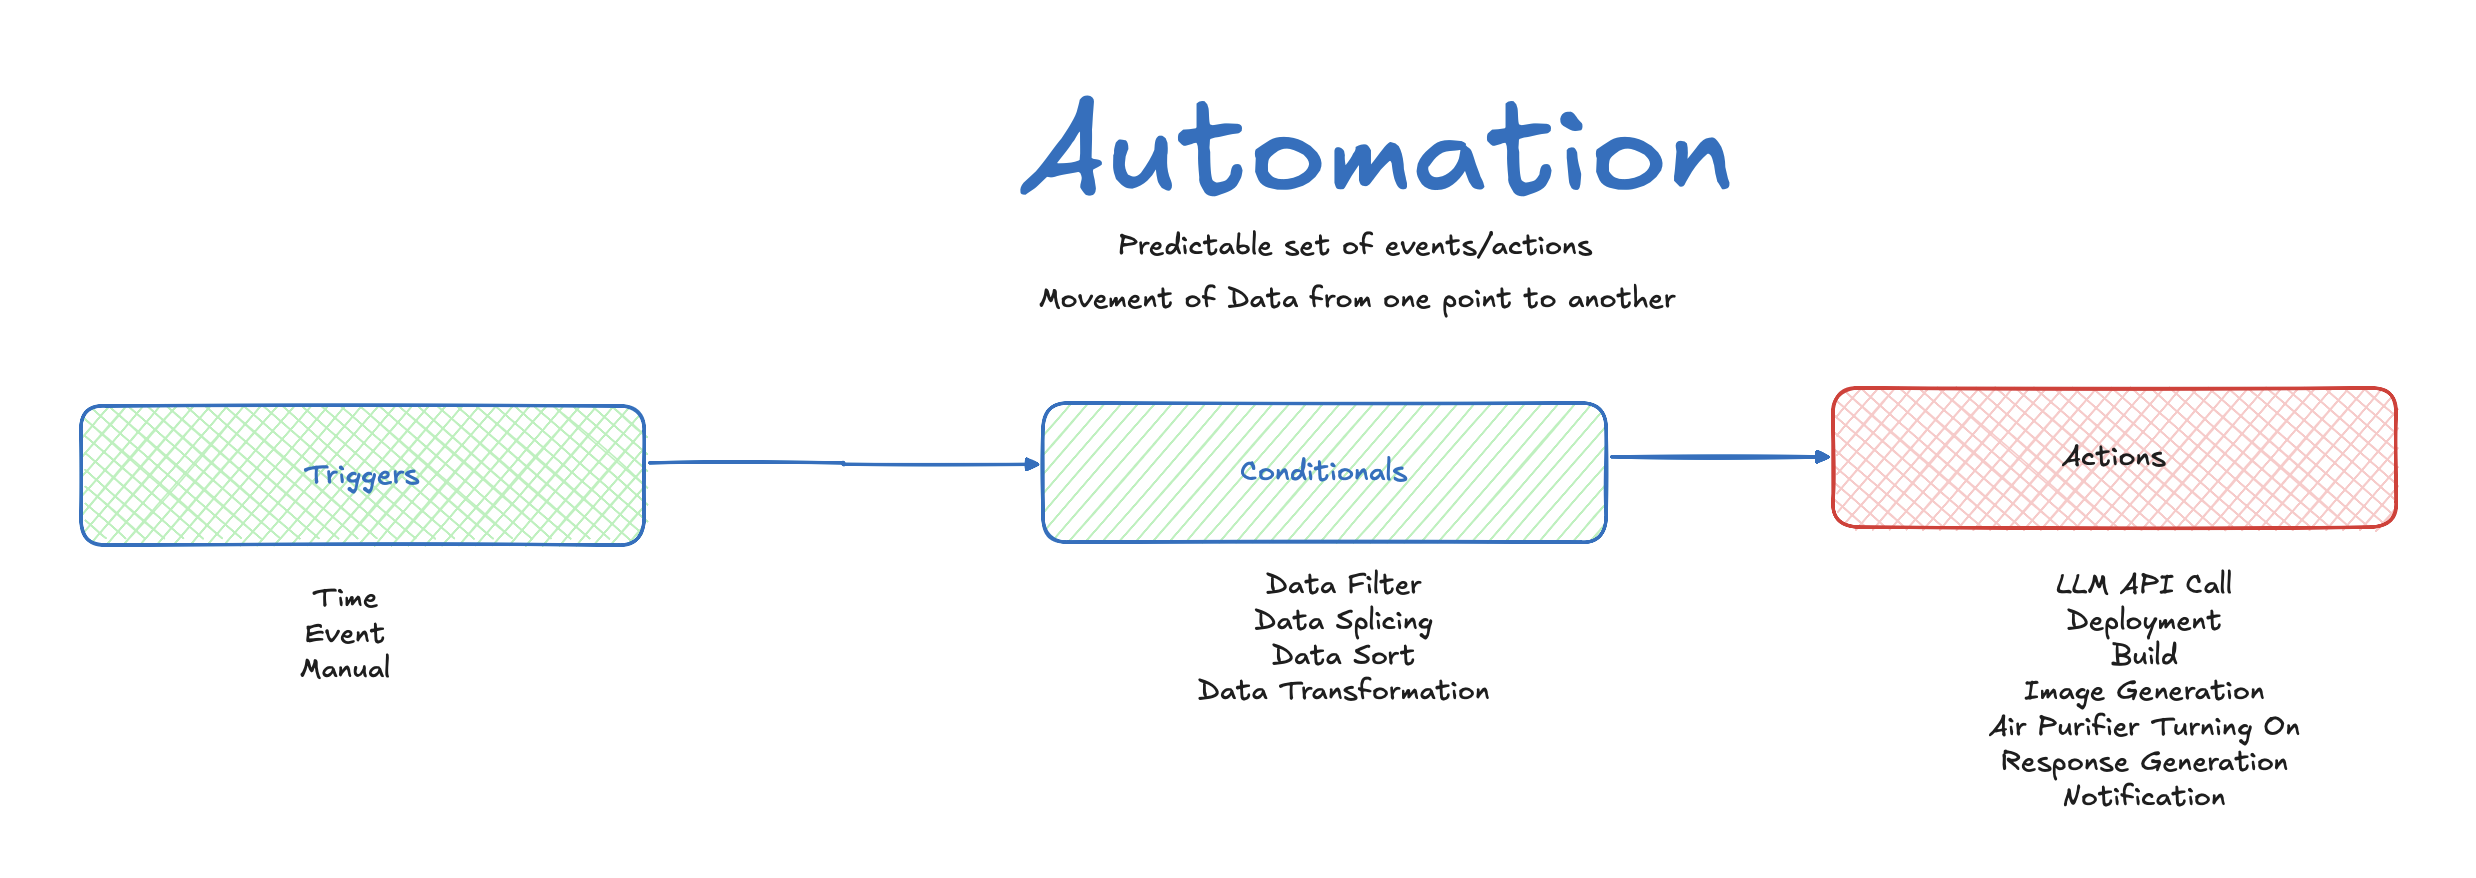

# Why Agentic AI is most suitable for Automation

* **Autonomous Problem Solving:** Agentic AI moves beyond passive, rule-based scripts by independently breaking down high-level goals into actionable steps, allowing it to manage complex, multi-stage workflows without constant human oversight.
* **Dynamic Adaptability:** Traditional automation breaks when it encounters undefined parameters or exceptions. Agentic AI uses reasoning to adjust its plans in real time, navigating around errors and changing environments to complete the task successfully.
* **Continuous Self-Improvement:** Through feedback loops and memory architectures, agentic systems learn from past interactions and outcomes. This allows them to refine their logic and optimize performance over time without requiring manual code updates.
* **Seamless System Integration:** These systems can independently search the web, query databases, and trigger actions across various external software applications via APIs, acting as a highly capable bridge between isolated business tools.
* **Context-Aware Decision Making:** Agentic AI understands nuanced, unstructured data. It interprets the broader context of a situation to weigh options and make informed decisions that align with overarching business objectives.

### Building Automations: Best Practices

- Understanding of the existing process
- Tools that will be used
- Feasibility of the automation
- Estimation of work load
- (Sometimes) need for human intervention

# Low-Code Automation Tools: A Hands-On Introduction to n8n


## 1. What is Low-Code?

Low-code platforms let you build working software through visual interfaces (drag-and-drop editors, prebuilt connectors, configuration forms) instead of writing everything from scratch. Code is still available when you need it, but it's the escape hatch rather than the default.

A quick vocabulary check, because these terms get mixed up constantly:

| Term | Who it's for | Code involved? | Example |
|---|---|---|---|
| **No-code** | Business users, non-programmers | None, by design | Zapier, Airtable |
| **Low-code** | Developers + technical users | Optional, for custom logic | n8n, Retool, Power Automate |
| **Pro-code** | Developers | All of it | Writing a Python service |

The distinction matters in practice. No-code tools hit a wall the moment your requirement isn't covered by a prebuilt option. Low-code tools let you drop into JavaScript or Python at that point and keep going.

### Why teams adopt these tools

- **Speed:** an integration that takes a developer 2 days in Python often takes 20 minutes in n8n
- **Maintenance:** the workflow *is* the documentation; anyone can open it and see what it does
- **Democratization:** analysts and ops people can build and modify automations without filing engineering tickets
- **Glue work:** most business automation is "when X happens in tool A, do Y in tool B." This is exactly what these platforms are optimized for

### Where they fall short

- Complex algorithms and heavy data processing still belong in real code
- Version control and testing are weaker than in a normal software workflow (n8n mitigates this since workflows are exportable JSON)
- Vendor lock-in is real for cloud-only tools like Zapier
- Debugging a 60-node workflow can be worse than debugging 200 lines of Python

## 2. The Tool Landscape

There are dozens of players. These six cover the categories worth knowing:

| Tool | Category | Hosting | Pricing model | Best for |
|---|---|---|---|---|
| **n8n** | Workflow automation | Self-hosted or cloud | Free (self-hosted, fair-code license); paid cloud | Technical teams who want control, custom code, AI agents |
| **Zapier** | Workflow automation | Cloud only | Per-task pricing | Non-technical users, huge app catalog (7,000+ apps) |
| **Make** (ex-Integromat) | Workflow automation | Cloud only | Per-operation pricing | Visual complex branching, cheaper than Zapier at scale |
| **Power Automate** | Workflow automation + RPA | Cloud + desktop | Per-user/per-flow, bundled with M365 | Organizations already deep in the Microsoft ecosystem |
| **Langflow** | LLM app builder | Self-hosted or cloud | Open source | Prototyping RAG pipelines and LLM chains visually |
| **Flowise** | LLM app builder | Self-hosted or cloud | Open source | Similar to Langflow; chatbot-oriented, LangChain-based |

Two different jobs are represented here:

1. **General workflow automation** (n8n, Zapier, Make, Power Automate): connect SaaS apps, move data, react to events
2. **LLM app builders** (Langflow, Flowise): visually wire up prompts, models, vector stores, and memory into AI applications

n8n is interesting because it now straddles both: since 2024 it ships native AI Agent nodes (LangChain-based), so you can build an agent with tools and memory in the same canvas where you handle your Slack notifications.

### Why n8n as the deep-dive choice?

- **Self-hostable:** one Docker command, your data never leaves your infrastructure. This matters for healthcare, finance, and education contexts
- **Fair-code licensed:** source available, free for internal use
- **Code when you need it:** JavaScript or Python in any workflow via the Code node
- **400+ integrations** plus generic HTTP Request and Webhook nodes that can talk to literally any API
- **Native AI capabilities:** agents, chains, vector store nodes, chat triggers

## 3. n8n Core Concepts

Everything in n8n reduces to five ideas.

### 3.1 Workflows
A workflow is a canvas of connected nodes, executed left to right. It's stored as JSON, which means workflows can be version-controlled, shared, and imported — we'll import one in Section 5.

### 3.2 Nodes
Nodes are the building blocks. Three broad kinds:

| Kind | Role | Examples |
|---|---|---|
| **Trigger nodes** | Start the workflow | Webhook, Schedule (cron), Chat Trigger, Gmail Trigger |
| **Action nodes** | Do something | HTTP Request, Google Sheets, Slack, Postgres |
| **Logic/transform/conditional nodes** | Route and reshape data | IF, Switch, Merge, Loop, Set (Edit Fields), Code |

### 3.3 Data model: items
Data flows between nodes as an **array of items**, each item being a JSON object:

```json
[
  { "json": { "name": "Asha",  "score": 91 } },
  { "json": { "name": "Rohan", "score": 78 } }
]
```

Key mental model: **most nodes run once per item.** If 5 items arrive at a Slack node, 5 messages get sent. This trips up every beginner exactly once.

### 3.4 Expressions
Anywhere you see a field, you can inject dynamic values with `{{ }}` syntax:

```
Hello {{ $json.name }}, your score is {{ $json.score }}
```

- `$json` → current item's data
- `$node["Node Name"].json` → output of a specific earlier node
- `$now`, `$today` → date helpers
- Full JavaScript works inside the braces: `{{ $json.score >= 80 ? "Pass" : "Review" }}`

### 3.5 Credentials
API keys and OAuth tokens are stored once, encrypted, and referenced by nodes — never pasted into workflows. This is what makes sharing workflow JSON safe: credentials are not embedded in the export.

### The AI layer (newer, worth knowing)
- **AI Agent node:** an LLM that can decide which connected tools to call (search, HTTP, database, your other workflows)
- **Chat Trigger:** gives a workflow a chat UI, so a workflow becomes a chatbot
- **Vector store + embedding nodes:** enough to build a basic RAG pipeline on the canvas
- **MCP support:** n8n can act as an MCP server/client, so tools like Claude can call your n8n workflows

# 4. Run n8n locally

```bash
docker volume create n8n_data
docker run -it --rm --name n8n -p 5678:5678 -v n8n_data:/home/node/.n8n docker.n8n.io/n8nio/n8n
```

Access the editor at `http://localhost:5678`

# Try any of these workflows:
* [Your First AI Agent](https://drive.google.com/file/d/1Rbq3xqiqBqL4IL3EL0O0r74Vpxsz_UXN/view?usp=sharing)
* [AI Newsletter Automation v0.1](https://drive.google.com/file/d/1SkEWZctqRWIkS78VA3VCLLZhhjEYygai/view?usp=sharing)
* [AI Newsletter Automation v1.0](https://drive.google.com/file/d/1Gv7TCKkDOkLe1rutI2kYTO2rQi0S5q3S/view?usp=sharing)

## 5. A Quick Look at the Other Tools

### Zapier
The market leader by app count. Linear "Zap" model: one trigger, then a sequence of actions. Excellent for simple A→B automations by non-technical users; gets expensive fast (per-task billing) and clumsy for branching logic. No self-hosting.

### Make (formerly Integromat)
Visual "scenario" canvas closer to n8n's, with strong support for routers, iterators, and aggregators. Generally cheaper than Zapier per operation. Still cloud-only, and the execution model (operations-based billing) needs watching on high-volume flows.

### Microsoft Power Automate
The default answer inside Microsoft shops: deep hooks into Teams, SharePoint, Excel, Dynamics, plus desktop RPA (recording UI clicks on legacy Windows apps — something none of the others do). Licensing is famously confusing; outside the M365 ecosystem there's little reason to pick it.

### Langflow and Flowise
Different category: these build **LLM applications**, not general automations. Both give you a canvas of LangChain components — prompts, models, vector stores, memory, agents — and both are open source and pip/npm installable (`pip install langflow`, `npx flowise`). Use them to prototype a RAG pipeline visually before committing it to code. n8n's AI nodes now cover much of this ground, so the lines are blurring.

### Decision framework

| Your situation | Reach for |
|---|---|
| Non-technical team, standard SaaS apps, simple flows | Zapier |
| Cost-sensitive, complex branching, still want cloud | Make |
| Everything lives in Microsoft 365 / need desktop RPA | Power Automate |
| Data sovereignty, custom code, AI agents, self-hosting | **n8n** |
| Prototyping an LLM/RAG app specifically | Langflow or Flowise |
| Heavy computation, complex algorithms, strict testing | Skip low-code; write real code |